# TASK-3   Car Price Prediction With Machine Learning

### Load the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn = for machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")   # hides unnecessary warnings
df = pd.read_csv("DataScience-Task3(Dataset)-CAR DETAILS FROM CAR DEKHO.csv")

In [2]:
df = pd.read_csv("DataScience-Task3(Dataset)-CAR DETAILS FROM CAR DEKHO.csv")
print(df.shape)      
df.head()           

(4340, 8)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [3]:
df.info()       

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [4]:
df.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


### Data Cleaning

In [5]:
print(df.isnull().sum())    # for missing values in each column

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64


In [6]:
df = df.dropna()  # Drop rows with missing values 

In [7]:
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicates after:", df.duplicated().sum())  # Checking for duplicates values

Duplicates before: 763
Duplicates after: 0


In [8]:
# Cateogry wise 
print(df["fuel"].unique())
print(df["transmission"].unique())
print(df["seller_type"].unique())
print(df["owner"].unique())

['Petrol' 'Diesel' 'CNG' 'LPG' 'Electric']
['Manual' 'Automatic']
['Individual' 'Dealer' 'Trustmark Dealer']
['First Owner' 'Second Owner' 'Fourth & Above Owner' 'Third Owner'
 'Test Drive Car']


In [9]:
text_cols = ["name", "fuel", "seller_type", "transmission", "owner"]

for col in text_cols:
    df[col] = df[col].str.strip().str.lower()

print(df["fuel"].unique())   # check again

['petrol' 'diesel' 'cng' 'lpg' 'electric']


### Feature Engineering

In [10]:
current_year = 2026  # car age
df["car_age"] = current_year - df["year"]
df["brand"] = df["name"].str.split().str[0]  # car brand name
print(df["brand"].value_counts())

brand
maruti           1072
hyundai           637
mahindra          328
tata              308
ford              220
honda             216
toyota            170
chevrolet         151
renault           110
volkswagen         93
nissan             52
skoda              49
fiat               32
audi               31
datsun             29
bmw                25
mercedes-benz      21
jaguar              5
mitsubishi          5
land                5
volvo               4
jeep                3
ambassador          3
mg                  2
opelcorsa           2
daewoo              1
force               1
isuzu               1
kia                 1
Name: count, dtype: int64


In [11]:
df = df.drop(["name", "year"], axis=1)
df.head()

,selling_price,km_driven,fuel,seller_type,transmission,owner,car_age,brand
0,60000,70000,petrol,individual,manual,first owner,19,maruti
1,135000,50000,petrol,individual,manual,first owner,19,maruti
2,600000,100000,diesel,individual,manual,first owner,14,hyundai
3,250000,46000,petrol,individual,manual,first owner,9,datsun
4,450000,141000,diesel,individual,manual,second owner,12,honda


### Exploratory Data Analysis (EDA)

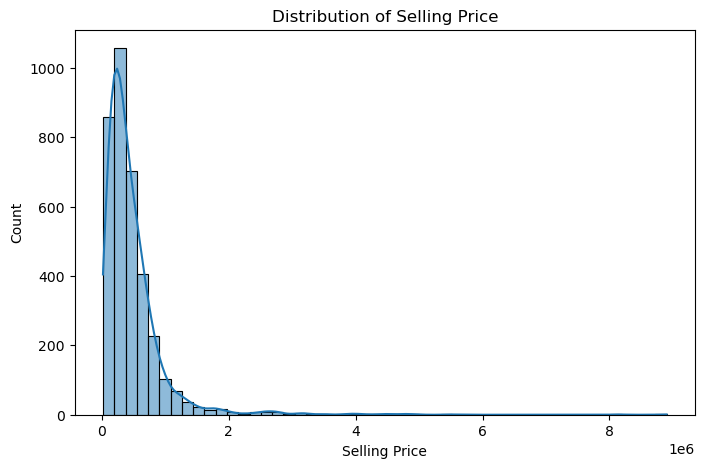

In [12]:
plt.figure(figsize=(8, 5)) # Distribution of saling prices
sns.histplot(df["selling_price"], bins=50, kde=True)
plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.show()

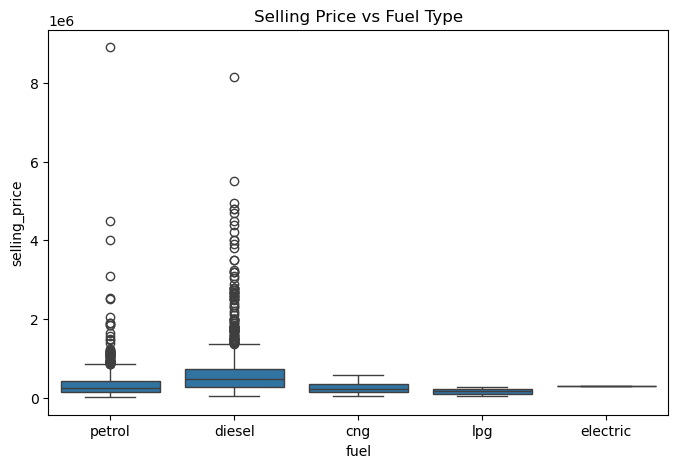

In [13]:
plt.figure(figsize=(8, 5))  #price vs Fuel Type
sns.boxplot(x="fuel", y="selling_price", data=df)
plt.title("Selling Price vs Fuel Type")
plt.show()

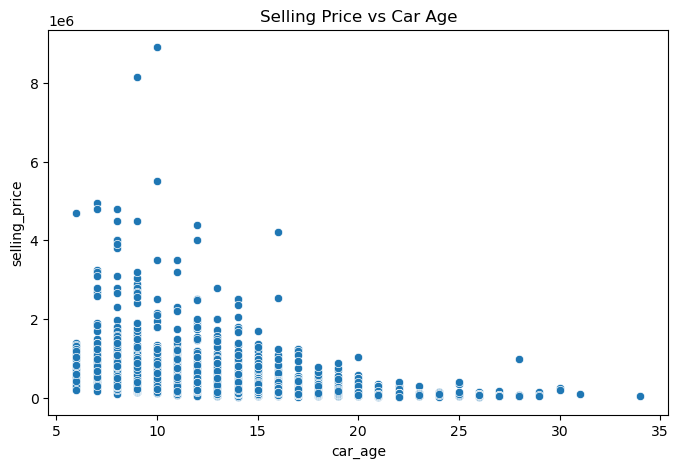

In [14]:
plt.figure(figsize=(8, 5))  #Price vs Car age
sns.scatterplot(x="car_age", y="selling_price", data=df)
plt.title("Selling Price vs Car Age")
plt.show()

### Encode Categorical Variable

In [15]:
df_encoded = pd.get_dummies(df, drop_first=True, dtype=int)

print(df_encoded.shape)
df_encoded.head()

(3577, 42)


,selling_price,km_driven,car_age,fuel_diesel,fuel_electric,fuel_lpg,fuel_petrol,seller_type_individual,seller_type_trustmark dealer,transmission_manual,...,brand_mg,brand_mitsubishi,brand_nissan,brand_opelcorsa,brand_renault,brand_skoda,brand_tata,brand_toyota,brand_volkswagen,brand_volvo
0,60000,70000,19,0,0,0,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
1,135000,50000,19,0,0,0,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
2,600000,100000,14,1,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
3,250000,46000,9,0,0,0,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
4,450000,141000,12,1,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0


### Correlation HeatMap

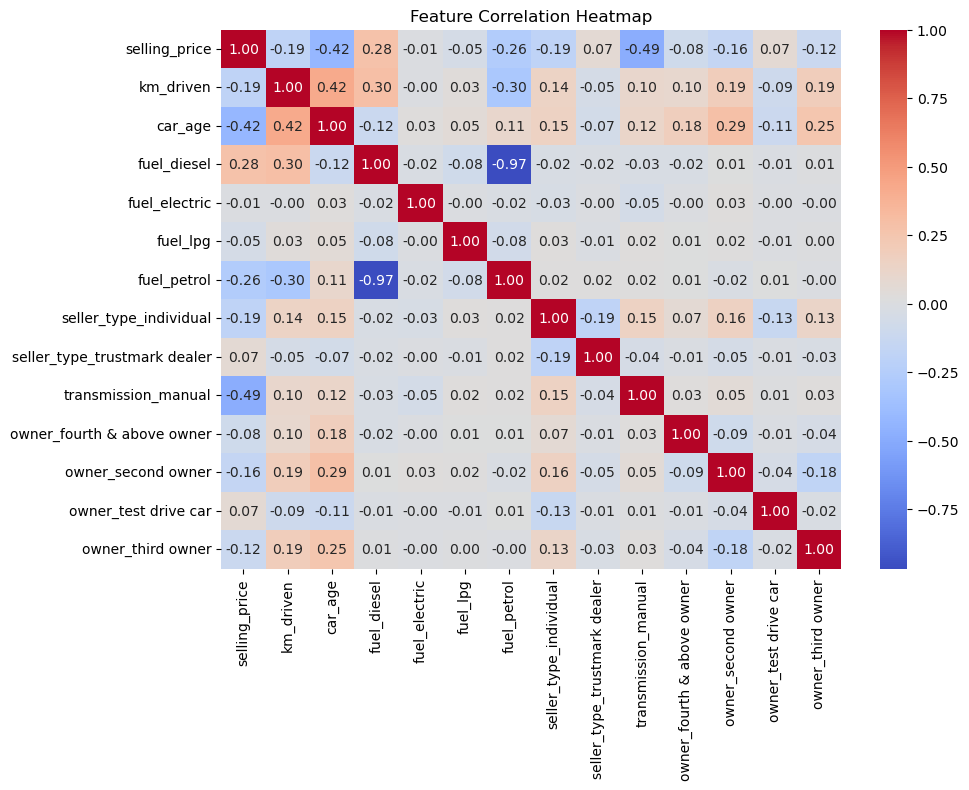

In [16]:
cols_for_heatmap = [c for c in df_encoded.columns if not c.startswith("brand_")]

plt.figure(figsize=(10, 7))
sns.heatmap(df_encoded[cols_for_heatmap].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

### Train/Test Split

In [17]:
# X = features (inputs), y = target (what we predict)
X = df_encoded.drop("selling_price", axis=1)
y = df_encoded["selling_price"]

# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (2861, 41)
Testing size: (716, 41)


### Train the model

In [18]:
# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)          # .fit() = "learn from this data"

# 2. Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 3. Gradient Boosting
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


### Evaluate the Models

In [19]:
# a small function so we don't repeat code three times
def evaluate_model(model, name):
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    print(name)
    print("  MAE :", round(mae, 2))
    print("  RMSE:", round(rmse, 2))
    print("  R2  :", round(r2, 4))
    print()

    return [name, mae, rmse, r2]

results = []
results.append(evaluate_model(lr, "Linear Regression"))
results.append(evaluate_model(rf, "Random Forest"))
results.append(evaluate_model(gb, "Gradient Boosting"))

# put everything in one neat table
results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])
results_df

Linear Regression
  MAE : 180194.99
  RMSE: 385606.09
  R2  : 0.5384

Random Forest
  MAE : 158918.38
  RMSE: 365567.41
  R2  : 0.5851

Gradient Boosting
  MAE : 157484.15
  RMSE: 377049.4
  R2  : 0.5587



,Model,MAE,RMSE,R2
0,Linear Regression,180194.987022,385606.086098,0.538415
1,Random Forest,158918.379218,365567.412752,0.585142
2,Gradient Boosting,157484.145675,377049.398798,0.558673


### Feature Importance Chart

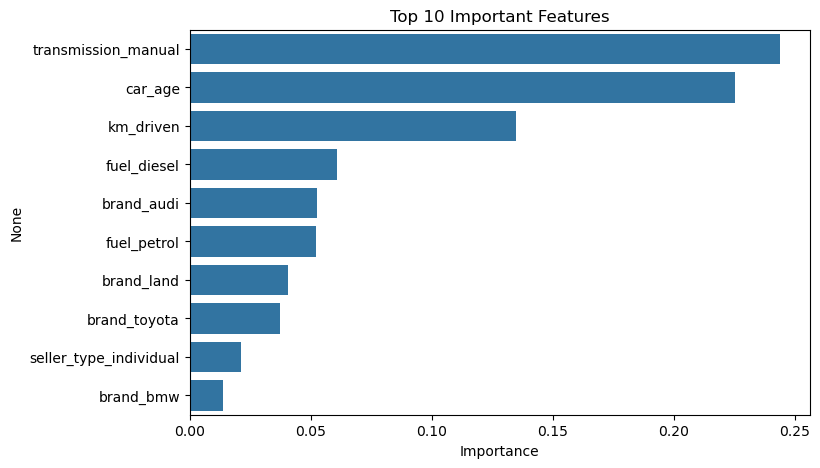

In [20]:
best_model = rf

importance = pd.Series(best_model.feature_importances_, index=X.columns)
top_features = importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.show()